In [47]:
import yfinance as yf
import pandas as pd

In [48]:
# df = yf.download('BTC-USD')
df = yf.download('BTC-USD')

C:\Users\VincentPham\AppData\Local\Temp\ipykernel_4488\1252289410.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD')
[*********************100%***********************]  1 of 1 completed


In [49]:
df

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-06-22,100987.140625,103351.632812,98286.203125,102212.031250,65536997201
2025-06-23,105577.773438,106116.859375,99705.750000,100987.476562,65237759656
2025-06-24,106045.632812,106316.828125,104740.242188,105571.515625,48822986421
2025-06-25,107361.257812,108168.398438,105881.390625,106047.406250,51624120283
2025-06-26,106960.000000,108305.546875,106666.351562,107375.070312,43891990613
2025-06-27,107088.429688,107772.468750,106449.992188,106954.921875,45353692675
2025-06-28,107327.703125,107567.882812,106883.976562,107090.546875,30037708335
2025-06-29,108385.570312,108526.304688,107230.109375,107327.820312,35534874438


In [50]:
df.to_csv('btc-usd.csv')


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30 entries, 2025-06-22 to 2025-07-22
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   30 non-null     float64
 1   (High, BTC-USD)    30 non-null     float64
 2   (Low, BTC-USD)     30 non-null     float64
 3   (Open, BTC-USD)    30 non-null     float64
 4   (Volume, BTC-USD)  30 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 1.4 KB


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error


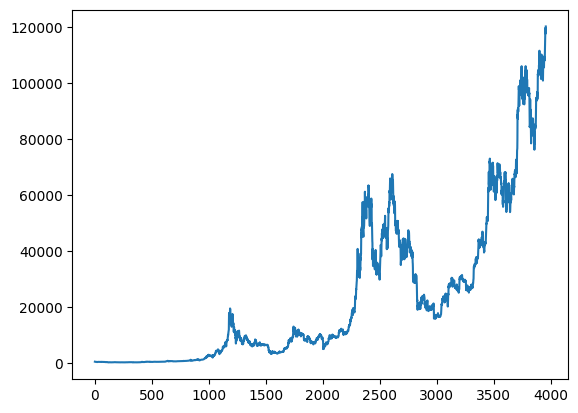

In [17]:
plt.plot(df.index, df['Close'])
plt.show()

In [18]:
to_row = int(len(df)*0.9)

training_data = df[0:to_row]['Close']
testing_data = df[to_row:]['Close']
training_data, testing_data

(0         457.334015
 1         424.440002
 2         394.795990
 3         408.903992
 4         398.821014
             ...     
 3556    68241.187500
 3557    66756.398438
 3558    66011.093750
 3559    66191.000000
 3560    66639.046875
 Name: Close, Length: 3561, dtype: float64,
 3561     66490.296875
 3562     65140.746094
 3563     64960.296875
 3564     64828.656250
 3565     64096.199219
             ...      
 3952    119116.117188
 3953    119849.703125
 3954    117777.187500
 3955    118738.507812
 3956    120341.109375
 Name: Close, Length: 396, dtype: float64)

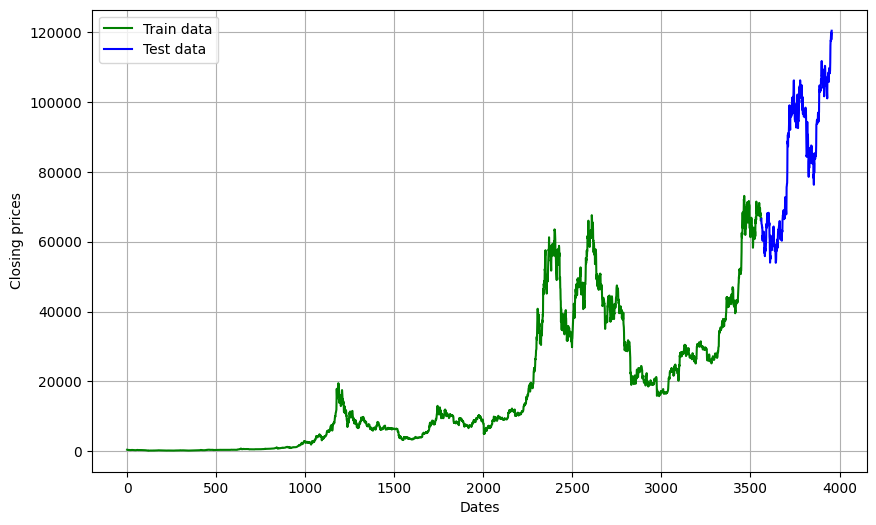

In [19]:
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing prices')
plt.plot(training_data, 'green', label='Train data')
plt.plot(testing_data, 'blue', label='Test data')
plt.legend()
plt.show()

In [20]:
model_predictions = []
n_test_obser = len(testing_data)

In [21]:
training_data

0         457.334015
1         424.440002
2         394.795990
3         408.903992
4         398.821014
            ...     
3556    68241.187500
3557    66756.398438
3558    66011.093750
3559    66191.000000
3560    66639.046875
Name: Close, Length: 3561, dtype: float64

In [22]:
# for i in range(n_test_obser):
#     model = ARIMA(training_data, order=(4,1,0))  # Sửa ở đây: dùng trực tiếp training_data
#     model_fit = model.fit()
#     output = model_fit.forecast()
#     yhat = output[0]
#     model_predictions.append(yhat)
#     actual_test_value = testing_data.iloc[i]
#     training_data = pd.concat([training_data, pd.Series([actual_test_value], index=[testing_data.index[i]])])
#     print(output)

In [23]:
# for i in range(n_test_obser):
#     model = ARIMA(training_data['BTC-USD'], order=(4,1,0))
#     model_fit = model.fit()
#     output = model_fit.forecast()
#     yhat = output[0]
#     model_predictions.append(yhat)
#     actual_test_value = testing_data.iloc[i]
#     training_data = pd.concat([training_data, pd.Series([actual_test_value], index=[testing_data.index[i]])])
#     print(output)

In [24]:
for i in range(n_test_obser):
    model = ARIMA(training_data, order=(4,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output.iloc[0]  # Sửa ở đây: dùng iloc[0]
    model_predictions.append(yhat)
    actual_test_value = testing_data.iloc[i]
    training_data = pd.concat([training_data, pd.Series([actual_test_value], index=[testing_data.index[i]])])
    print(output)

3561    66539.10526
dtype: float64
3562    66481.912505
dtype: float64
3563    65233.828276
dtype: float64
3564    64967.097797
dtype: float64
3565    64786.710884
dtype: float64
3566    64079.379951
dtype: float64
3567    64224.975787
dtype: float64
3568    63213.693982
dtype: float64
3569    60398.95018
dtype: float64
3570    61659.941729
dtype: float64
3571    60750.810526
dtype: float64
3572    61491.007996
dtype: float64
3573    60429.189187
dtype: float64
3574    60825.819678
dtype: float64
3575    62573.497917
dtype: float64
3576    62833.447214
dtype: float64
3577    62154.139528
dtype: float64
3578    60339.342581
dtype: float64
3579    57106.063683
dtype: float64
3580    56554.96697
dtype: float64
3581    58060.583603
dtype: float64
3582    55875.599463
dtype: float64
3583    56669.775221
dtype: float64
3584    57926.435345
dtype: float64
3585    57712.368782
dtype: float64
3586    57435.098691
dtype: float64
3587    57902.546216
dtype: float64
3588    59142.637482
dtype: flo

In [25]:
len(model_predictions)

396

In [26]:
model_predictions

[66539.10526010321,
 66481.91250458518,
 65233.82827639813,
 64967.097796703354,
 64786.71088365627,
 64079.37995069379,
 64224.97578672599,
 63213.693982373756,
 60398.95017994578,
 61659.9417292835,
 60750.81052588985,
 61491.00799556948,
 60429.18918683362,
 60825.819678235,
 62573.4979166047,
 62833.447214117485,
 62154.1395279284,
 60339.34258116381,
 57106.06368311415,
 56554.966970316,
 58060.58360300229,
 55875.59946326068,
 56669.77522134994,
 57926.435345330334,
 57712.36878169591,
 57435.09869145445,
 57902.54621576927,
 59142.637482488804,
 60721.135017322515,
 64743.54406190925,
 65234.29862181871,
 64354.1072607278,
 64117.26807059823,
 66547.54737956607,
 67125.78943434484,
 68190.19624114278,
 67741.66314594736,
 66050.6491741427,
 65400.95415494557,
 65681.65075826597,
 67736.75600232123,
 67830.31120554796,
 68308.43413263309,
 66966.79684520893,
 66225.99427570908,
 64665.48747427079,
 65239.042505212135,
 61554.003091869214,
 60629.56343548069,
 58145.6304039179,
 5

In [27]:
model_predictions_df = pd.DataFrame(model_predictions, columns=['Predicted'])
model_predictions_df.to_csv('model_predictions.csv', index=False)

In [28]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3956
Model:                 ARIMA(4, 1, 0)   Log Likelihood              -33100.661
Date:                Tue, 22 Jul 2025   AIC                          66211.322
Time:                        09:46:33   BIC                          66242.736
Sample:                             0   HQIC                         66222.464
                               - 3956                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0530      0.008     -6.567      0.000      -0.069      -0.037
ar.L2          0.0106      0.009      1.212      0.226      -0.007       0.028
ar.L3          0.0037      0.009      0.396      0.692      -0.015       0.022
ar.L4          0.0188      0.008      2.261      0.024       0.002       0.035
sigma2       1.09e+06   9411.022    115.832      0.000    1.07e+06    1.11e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             23475.55
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              26.90   Skew:                             0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

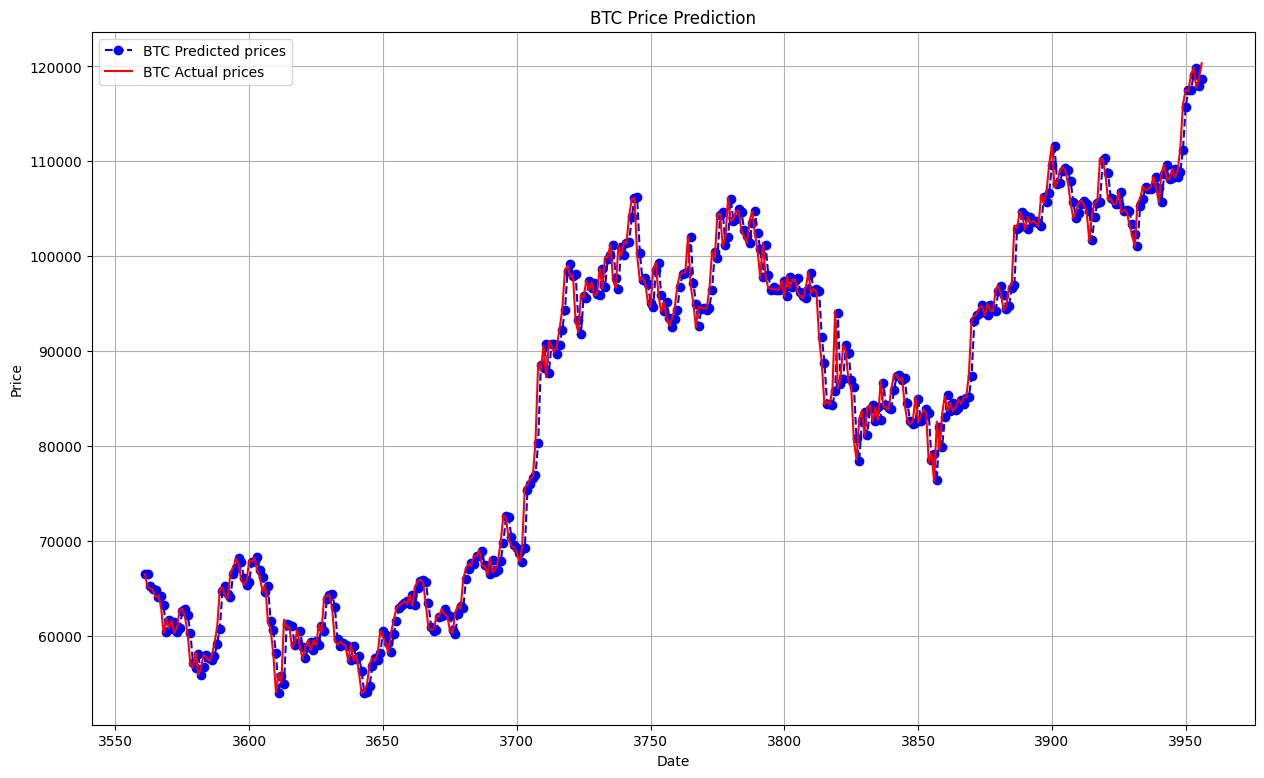

In [29]:
plt.figure(figsize=(15,9))
plt.grid()

data_range = df[to_row:].index

plt.plot(data_range, model_predictions, color = 'blue', marker = 'o', linestyle = 'dashed', label = 'BTC Predicted prices')
plt.plot(data_range, testing_data, color = 'red', label = 'BTC Actual prices')

plt.title('BTC Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Save the plot before showing
plt.savefig('btc_price_prediction.png', dpi=300, bbox_inches='tight')  # Lưu với độ phân giải cao

plt.show()

In [30]:
mape = np.mean(np.abs(np.array(testing_data) - np.array(model_predictions))/np.array(testing_data))

mse = mean_absolute_error(testing_data, model_predictions)

rmse = root_mean_squared_error(testing_data, model_predictions)

mae = mean_absolute_error(testing_data, model_predictions)

In [31]:
print('Mean Absolute Percentage Error: ' + str(mape))
print('Mean Squared Error: ' + str(mse))
print('Root Mean Squared Error: ' + str(rmse))
print('Mean Absolute Error: ' + str(mae))

Mean Absolute Percentage Error: 0.01814663894721981
Mean Squared Error: 1495.1619364240003
Root Mean Squared Error: 2089.543959402498
Mean Absolute Error: 1495.1619364240003


In [ ]:
import joblib

model_fit.save('btc_arima_model.keras')

In [33]:
# Create a DataFrame to store the predictions and actual values
results_df = pd.DataFrame({
    'Date': data_range,
    'Predicted': model_predictions,
    'Actual': testing_data.values
})

# Add the metrics to the DataFrame
results_df['MAPE'] = mape
results_df['MAE'] = mae
results_df['MSE'] = mse
results_df['RMSE'] = rmse

# Save the DataFrame to a CSV file
results_df.to_csv('btc_predictions_and_metrics.csv', index=False)

In [34]:
result_dir = "./Result"
results_df.to_csv(f"{result_dir}/btc_predictions_and_metrics.csv", index=False)

In [35]:
a = pd.read_csv(f"model_predictions.csv")

In [36]:
a

,Predicted
0,66539.105260
1,66481.912505
2,65233.828276
3,64967.097797
4,64786.710884
...,...
391,117503.692316
392,119118.700321
393,119859.915986
394,117898.039484
